In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pubchempy as pcp
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

from rdkit import Chem
from rdkit.Chem import Descriptors, rdPartialCharges
from rdkit.Chem.MolStandardize import rdMolStandardize

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = "../data/Data.csv"
TARGET_COL = "Removal %"
TIME_COL = "Rxn Time (min)"
DYE_COL = "Dye"
CORR_THRESHOLD = 0.85


In [22]:
df = pd.read_csv(DATA_PATH)

required_cols = [DYE_COL, TARGET_COL, TIME_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing columns: {missing_cols}")

df[DYE_COL] = df[DYE_COL].astype(str).str.strip()
print("Shape:", df.shape)
print("Unique dyes:", df[DYE_COL].nunique())
display(df.head())


Shape: (162, 3)
Unique dyes: 27


,Dye,Rxn Time (min),Removal %
0,MB,0,0.000000
1,MB,5,0.630870
2,MB,10,0.665654
3,MB,15,0.707449
4,MB,20,0.742452


In [23]:
dye_name_map = {
    "MB": "Methylene Blue",
    "MO": "Methyl Orange",
    "Tart": "Tartrazine",
    "RhB": "Rhodamine B",
    "R6G": "Rhodamine 6G",
    "Am": "Amaranth",
    "CV": "Crystal Violet",
    "MaG": "Malachite Green",
    "Ab": "Amido Black 10B",
    "PonS": "Ponceau S",
    "BBR": "Coomassie Brilliant Blue R-250",
    "BBG": "Coomassie Brilliant Blue G-250",
    "CB": "Cibacron Blue 3GA",
    "BPB": "Bromophenol Blue",
    "Erio": "Erioglaucine",
    "Reso": "Resorufin",
    "DR80": "Direct Red 80",
    "Congo": "Congo Red",
    "DMMB": "Dimethylmethylene Blue",
    "BF": "Basic Fuchsin",
    "Fl": "Fluorescein",
    "NBA": "Nile Blue A",
    "OG": "Orange G",
    "CS-3B": "Crocein Scarlet 3B",
    "FBMBSN": "Solvent Blue 38",
    "MG": "Methyl green chloride",
    "BCB": "Brilliant Cresyl Blue ALD",
}

unique_dyes = df[DYE_COL].dropna().unique().tolist()
missing_names = [d for d in unique_dyes if d not in dye_name_map]
if missing_names:
    print("Missing from dye_name_map:", missing_names)


In [24]:
def fetch_smiles_from_pubchem(dye_code):
    """Fetch canonical SMILES."""
    name = dye_name_map.get(str(dye_code).strip())
    if name is None:
        return None
    try:
        compounds = pcp.get_compounds(name, namespace="name")
        if not compounds:
            print(f"[PUBCHEM FAILED] {dye_code} -> {name}")
            return None
        return compounds[0].canonical_smiles
    except Exception as exc:
        print(f"[PUBCHEM ERROR] {dye_code}: {exc}")
        return None


def standardize_parent_mol(smiles):
    """Keep the main molecular fragment."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    chooser = rdMolStandardize.LargestFragmentChooser()
    parent = chooser.choose(mol)
    Chem.SanitizeMol(parent)
    return parent


In [25]:
def get_gasteiger_qc_min(mol):
    """Minimum Gasteiger charge on carbon."""
    mol_h = Chem.AddHs(Chem.Mol(mol))
    rdPartialCharges.ComputeGasteigerCharges(mol_h)
    values = []
    for atom in mol_h.GetAtoms():
        if atom.GetSymbol() != "C":
            continue
        try:
            q = float(atom.GetProp("_GasteigerCharge"))
        except (KeyError, ValueError):
            continue
        if np.isfinite(q):
            values.append(q)
    return min(values) if values else np.nan


def conjugated_bond_fraction(mol):
    n_bonds = mol.GetNumBonds()
    if n_bonds == 0:
        return 0.0
    return sum(int(b.GetIsConjugated()) for b in mol.GetBonds()) / n_bonds


def count_azo_groups(mol):
    pattern = Chem.MolFromSmarts("[#7]=[#7]")
    return len(mol.GetSubstructMatches(pattern))


In [26]:
def extract_chemical_features(dye_list):
    rows = []
    for dye_code in dye_list:
        dye_code = str(dye_code).strip()
        print("Processing:", dye_code)
        smiles = fetch_smiles_from_pubchem(dye_code)
        if not smiles:
            continue
        mol = standardize_parent_mol(smiles)
        if mol is None:
            print(f"[RDKIT FAILED] {dye_code}")
            continue

        mw = Descriptors.MolWt(mol)
        tpsa = Descriptors.TPSA(mol)

        rows.append({
            "Dye": dye_code,
            "Full_Name": dye_name_map[dye_code],
            "SMILES": smiles,
            "Parent_SMILES": Chem.MolToSmiles(mol),
            "MW": mw,
            "Relative_TPSA": tpsa / mw if mw > 0 else np.nan,
            "LogP": Descriptors.MolLogP(mol),
            "Conjugated_Bond_Fraction": conjugated_bond_fraction(mol),
            "Gasteiger_qC_Min": get_gasteiger_qc_min(mol),
            "Azo_Count": count_azo_groups(mol),
        })
    return pd.DataFrame(rows)


In [27]:
dye_features = extract_chemical_features(unique_dyes)

CORE_FEATURES = [
    "MW",
    "Relative_TPSA",
    "LogP",
    "Conjugated_Bond_Fraction",
    "Gasteiger_qC_Min",
]
EXTENDED_FEATURES = CORE_FEATURES + ["Azo_Count"]

display(dye_features)


Processing: MB


[11:36:17] Running LargestFragmentChooser
[11:36:17] Fragment: CN(C)c1ccc2nc3ccc(=[N+](C)C)cc-3sc2c1
[11:36:17] New largest fragment: CN(C)c1ccc2nc3ccc(=[N+](C)C)cc-3sc2c1 (38)
[11:36:17] Fragment: [Cl-]


Processing: MO


[11:36:18] Running LargestFragmentChooser
[11:36:18] Fragment: CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1
[11:36:18] New largest fragment: CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1 (35)
[11:36:18] Fragment: [Na+]


Processing: Tart


...

Processing: BCB


[11:36:43] Running LargestFragmentChooser
[11:36:43] Fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1
[11:36:43] New largest fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1 (41)
[11:36:43] Fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1
[11:36:43] New largest fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1 (41)
[11:36:43] Fragment: [Cl][Zn-2]([Cl])([Cl])[Cl]


Processing: CS-3B


[11:36:44] Running LargestFragmentChooser
[11:36:44] Fragment: O=S(=O)([O-])c1cc(S(=O)(=O)[O-])c2c(N=Nc3ccc(N=Nc4ccccc4)cc3)c(O)ccc2c1
[11:36:44] New largest fragment: O=S(=O)([O-])c1cc(S(=O)(=O)[O-])c2c(N=Nc3ccc(N=Nc4ccccc4)cc3)c(O)ccc2c1 (49)
[11:36:44] Fragment: [Na+]
[11:36:44] Fragment: [Na+]


,Dye,Full_Name,SMILES,Parent_SMILES,MW,Relative_TPSA,LogP,Conjugated_Bond_Fraction,Gasteiger_qC_Min,Azo_Count
0,MB,Methylene Blue,CN(C)C1=CC2=C(C=C1)N=C3C=CC(=[N+](C)C)C=C3S2.[...,CN(C)c1ccc2nc3ccc(=[N+](C)C)cc-3sc2c1,284.408,0.067298,2.49890,0.818182,-0.036529,0
1,MO,Methyl Orange,CN(C)C1=CC=C(C=C1)N=NC2=CC=C(C=C2)S(=O)(=O)[O-...,CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1,304.351,0.279809,3.07210,0.727273,-0.042443,1
2,Tart,Tartrazine,C1=CC(=CC=C1N=NC2C(=NN(C2=O)C3=CC=C(C=C3)S(=O)...,O=C([O-])C1=NN(c2ccc(S(=O)(=O)[O-])cc2)C(=O)C1...,465.401,0.455349,-0.90020,0.666667,-0.042508,1
3,RhB,Rhodamine B,CCN(CC)C1=CC2=C(C=C1)C(=C3C=CC(=[N+](CC)CC)C=C...,CCN(CC)c1ccc2c(-c3ccccc3C(=O)O)c3ccc(=[N+](CC)...,443.567,0.127805,5.56100,0.777778,-0.061599,0
4,R6G,Rhodamine 6G,CCNC1=CC2=C(C=C1C)C(=C3C=C(C(=[NH+]CC)C=C3O2)C...,CCNc1cc2oc3cc(=[NH+]CC)c(C)cc-3c(-c3ccccc3C(=O...,443.567,0.147531,4.43114,0.777778,-0.061599,0
5,Am,Amaranth,C1=CC=C2C(=C1)C(=CC=C2S(=O)(=O)[O-])N=NC3=C4C=...,O=S(=O)([O-])c1ccc2c(N=Nc3ccc(S(=O)(=O)[O-])c4...,535.513,0.404379,2.82630,0.684211,-0.061585,1
6,CV,Crystal Violet,CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=...,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccc(N(C)...,372.536,0.025474,4.45960,0.800000,-0.052279,0
7,MaG,Malachite Green,CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=...,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccccc2)cc1,329.467,0.018970,4.39360,0.851852,-0.062225,0
8,Ab,Amido Black 10B,C1=CC=C(C=C1)N=NC2=C(C3=C(C(=C(C=C3C=C2S(=O)(=...,Nc1c(N=Nc2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O-]...,570.521,0.443857,4.67480,0.809524,-0.062113,2
9,PonS,Ponceau S,C1=CC(=CC=C1N=NC2=CC(=C(C=C2)N=NC3=C4C=CC(=CC4...,O=S(=O)([O-])c1ccc(N=Nc2ccc(N=Nc3c(O)c(S(=O)(=...,668.621,0.446396,2.99260,0.652174,-0.050742,2


In [28]:
constant_features = [
    c for c in EXTENDED_FEATURES
    if dye_features[c].nunique(dropna=True) <= 1
]

features = [c for c in EXTENDED_FEATURES if c not in constant_features]
print("Constant features removed:", constant_features)
print("Initial features:", features)


Constant features removed: []
Initial features: ['MW', 'Relative_TPSA', 'LogP', 'Conjugated_Bond_Fraction', 'Gasteiger_qC_Min', 'Azo_Count']


In [29]:
def prune_correlated_features(data, feature_list, threshold=0.85):
    corr = data[feature_list].corr().abs()
    kept, dropped = [], {}

    for feature in feature_list:
        conflict = None
        for previous in kept:
            r = corr.loc[feature, previous]
            if np.isfinite(r) and r >= threshold:
                conflict = previous
                break
        if conflict is None:
            kept.append(feature)
        else:
            dropped[feature] = {"correlated_with": conflict, "abs_r": r}

    return kept, dropped


selected_features, dropped_features = prune_correlated_features(
    dye_features, features, CORR_THRESHOLD
)

print("Selected features:", selected_features)
if dropped_features:
    display(pd.DataFrame(dropped_features).T)


Selected features: ['MW', 'Relative_TPSA', 'LogP', 'Conjugated_Bond_Fraction', 'Gasteiger_qC_Min', 'Azo_Count']


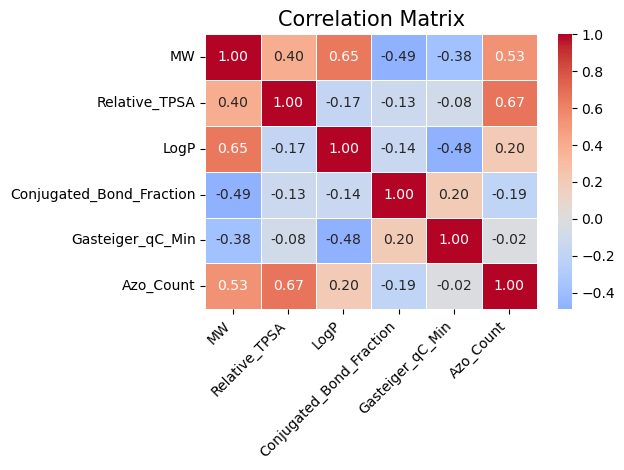

In [30]:
corr = dye_features[selected_features].corr()

# CORRELATION MATRIX
corr = dye_features[selected_features].corr()

plt.figure()

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
X_vif = dye_features[selected_features].replace([np.inf, -np.inf], np.nan).copy()
X_vif = X_vif.fillna(X_vif.median())
X_vif_const = add_constant(X_vif)

vif_table = pd.DataFrame({
    "Feature": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

vif_table = (
    vif_table[vif_table["Feature"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_table)


,Feature,VIF
0,MW,5.243215
1,LogP,4.864654
2,Relative_TPSA,3.970146
3,Azo_Count,2.581630
4,Conjugated_Bond_Fraction,1.702464
5,Gasteiger_qC_Min,1.632076


In [32]:
df_model = df.merge(
    dye_features[["Dye"] + selected_features],
    on="Dye",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", df_model.shape)


Merged shape: (162, 9)


In [33]:
raw_corr = (
    df_model[[TARGET_COL, TIME_COL] + selected_features]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=np.abs, ascending=False)
)

display(raw_corr.to_frame("Pearson_Correlation"))


,Pearson_Correlation
Rxn Time (min),0.832799
MW,-0.236862
LogP,-0.186716
Azo_Count,-0.150244
Gasteiger_qC_Min,0.077532
Conjugated_Bond_Fraction,0.073868
Relative_TPSA,-0.057228


In [34]:
valid_mask = df_model[[DYE_COL, TARGET_COL, TIME_COL]].notna().all(axis=1)
work = df_model.loc[valid_mask].copy()

n_groups = work[DYE_COL].nunique()
if n_groups < 2:
    raise ValueError("At least two dyes are required.")

n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

time_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

oof_pred = cross_val_predict(
    time_model,
    work[[TIME_COL]],
    work[TARGET_COL],
    groups=work[DYE_COL],
    cv=gkf,
    n_jobs=-1,
)

work["Time_Only_OOF_Prediction"] = oof_pred
work["Time_Adjusted_Removal"] = work[TARGET_COL] - oof_pred

df_model["Time_Only_OOF_Prediction"] = np.nan
df_model["Time_Adjusted_Removal"] = np.nan

df_model.loc[work.index, "Time_Only_OOF_Prediction"] = work["Time_Only_OOF_Prediction"]
df_model.loc[work.index, "Time_Adjusted_Removal"] = work["Time_Adjusted_Removal"]


In [35]:
dye_residuals = (
    df_model.groupby(DYE_COL, as_index=False)
    .agg(
        Mean_Time_Adjusted_Removal=("Time_Adjusted_Removal", "mean"),
        Median_Time_Adjusted_Removal=("Time_Adjusted_Removal", "median"),
        N_Observations=("Time_Adjusted_Removal", "count"),
    )
)

dye_analysis = dye_residuals.merge(
    dye_features[["Dye", "Full_Name"] + selected_features],
    on="Dye",
    how="left",
    validate="one_to_one"
)

display(dye_analysis)


,Dye,Mean_Time_Adjusted_Removal,Median_Time_Adjusted_Removal,N_Observations,Full_Name,MW,Relative_TPSA,LogP,Conjugated_Bond_Fraction,Gasteiger_qC_Min,Azo_Count
0,Ab,0.034549,0.039623,6,Amido Black 10B,570.521,0.443857,4.67480,0.809524,-0.062113,2
1,Am,0.089717,0.097766,6,Amaranth,535.513,0.404379,2.82630,0.684211,-0.061585,1
2,BBG,-0.085080,-0.094905,6,Coomassie Brilliant Blue G-250,831.049,0.170760,8.96362,0.687500,-0.060672,0
3,BBR,-0.063856,-0.065272,6,Coomassie Brilliant Blue R-250,802.995,0.176726,8.26510,0.709677,-0.060672,0
4,BCB,-0.011193,-0.006383,6,Brilliant Cresyl Blue ALD,282.367,0.194994,2.63522,0.782609,-0.037650,0
5,BF,0.188739,0.239020,6,Basic Fuchsin,301.393,0.251797,4.18877,0.960000,-0.052293,0
6,BPB,0.004095,-0.004051,6,Bromophenol Blue,669.967,0.125126,6.15860,0.625000,-0.061772,0
7,CB,-0.290331,-0.351383,6,Cibacron Blue 3GA,774.171,0.384967,3.85350,0.767857,-0.061485,0
8,CS-3B,-0.064213,-0.068292,6,Crocein Scarlet 3B,510.509,0.360562,5.18440,0.789474,-0.062113,2
9,CV,0.066713,0.079519,6,Crystal Violet,372.536,0.025474,4.45960,0.800000,-0.052279,0


In [36]:
dye_level_corr = (
    dye_analysis[["Mean_Time_Adjusted_Removal"] + selected_features]
    .corr(numeric_only=True)["Mean_Time_Adjusted_Removal"]
    .drop("Mean_Time_Adjusted_Removal")
    .sort_values(key=np.abs, ascending=False)
)

display(dye_level_corr.to_frame("Dye_Level_Correlation"))


,Dye_Level_Correlation
MW,-0.564134
LogP,-0.434754
Azo_Count,-0.340102
Conjugated_Bond_Fraction,0.183293
Gasteiger_qC_Min,0.156639
Relative_TPSA,-0.125781


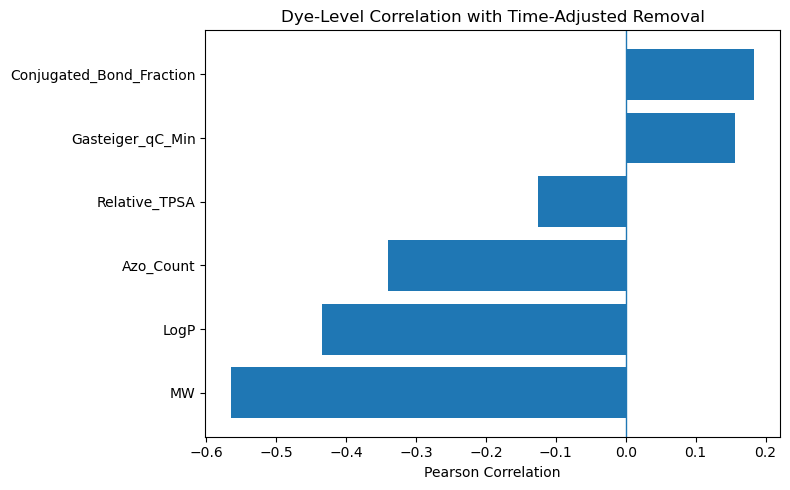

In [37]:
plot_values = dye_level_corr.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_values.index, plot_values.values)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Pearson Correlation")
ax.set_title("Dye-Level Correlation with Time-Adjusted Removal")
fig.tight_layout()
plt.show()


In [38]:
core_available = [c for c in CORE_FEATURES if c in selected_features]

core_corr = (
    dye_analysis[["Mean_Time_Adjusted_Removal"] + core_available]
    .corr(numeric_only=True)["Mean_Time_Adjusted_Removal"]
    .drop("Mean_Time_Adjusted_Removal")
    .sort_values(key=np.abs, ascending=False)
)

print("Core feature set:")
display(core_corr.to_frame("Dye_Level_Correlation"))


Core feature set:


,Dye_Level_Correlation
MW,-0.564134
LogP,-0.434754
Conjugated_Bond_Fraction,0.183293
Gasteiger_qC_Min,0.156639
Relative_TPSA,-0.125781


In [39]:
# dye_features[
#     ["Dye", "Full_Name", "SMILES", "Parent_SMILES"] + selected_features
# ].to_csv("../data/Dye_Descriptors_Optimized_v2.csv", index=False)

# df_model.to_csv("../data/Data_with_Optimized_Descriptors_v2.csv", index=False)
# dye_analysis.to_csv("../data/Dye_Level_Time_Adjusted_Analysis_v2.csv", index=False)

# print("Saved.")
